In [50]:
## Imports and Initialization -------------------------------------------------|
print("Importing dependencies... ")

import random, math
import sys, time
import os, os.path
sys.path.insert(0, "..")

# third party
import numpy as np
from astropy.io import fits
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

# internal
import abstraction
import algorithm
from astropy.io import fits
from utility import IndexSchema, get_fits_paths, load_image_data
from examples.fits_to_mp4 import fits_to_mp4, data_to_mp4
from reference_method import ExternalRefs, RollingWindow

## Fetch Data ------------------------------------------------------------------

frame_num = 3

files_dir = os.path.abspath(os.path.join(".", "media"))
files = get_fits_paths(files_dir)
files = files[frame_num:frame_num + 2]
# print("\n".join(files))
print(f"{len(files)} files found")

# create variable paths for destretching files
kernel_sizes: np.ndarray[np.int64] = np.array([16])
out_off_dir = os.path.join(files_dir, "off")
out_off_dir_ccfilt = os.path.join(out_off_dir, "ccfilt")

Importing dependencies... 
2 files found


# Calculate offsets between two images

In [2]:
start = time.time()

# calculate offset vectors
algorithm.USE_CC_FILTERING = False
abstraction.calc_offset_vectors(
	files,
	out_off_dir,
	"off",
	kernel_sizes=kernel_sizes,
)

correlations = algorithm.SUBFIELD_CORRS

algorithm.USE_CC_FILTERING = True
abstraction.calc_offset_vectors(
	files,
	out_off_dir_ccfilt,
	"off",
	kernel_sizes=kernel_sizes,
)

elapsed = time.time() - start
print(f"elapsed time: {elapsed}")

Searching for image data in specified files...
processing image #0../home/tteck/Documents/development/flct_destretch/flctdestretch/examples/media/test_1k_02.fits
processing image #1../home/tteck/Documents/development/flct_destretch/flctdestretch/examples/media/test_1k_03.fits
Searching for image data in specified files...
processing image #0../home/tteck/Documents/development/flct_destretch/flctdestretch/examples/media/test_1k_02.fits
processing image #1../home/tteck/Documents/development/flct_destretch/flctdestretch/examples/media/test_1k_03.fits
elapsed time: 18.3683660030365


# Visualize artifacts by plotting log-scale values (very dark and light spots are artifacts)

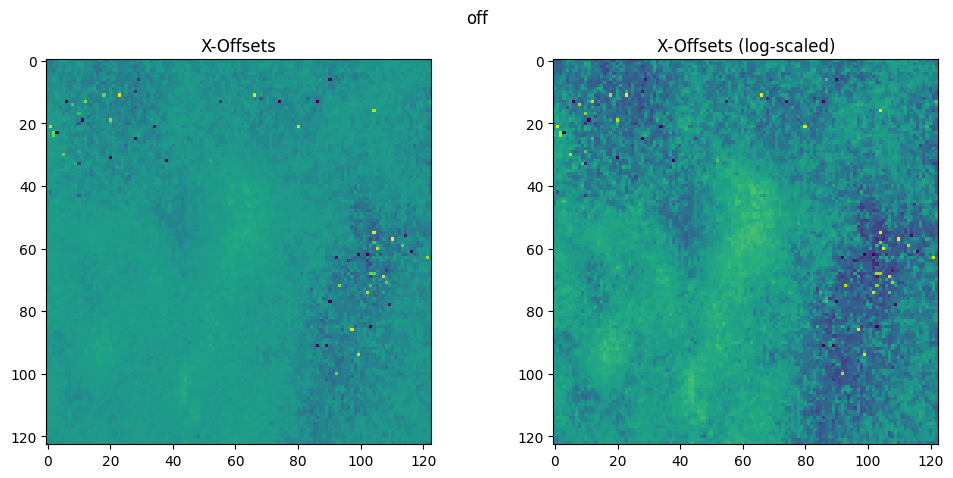

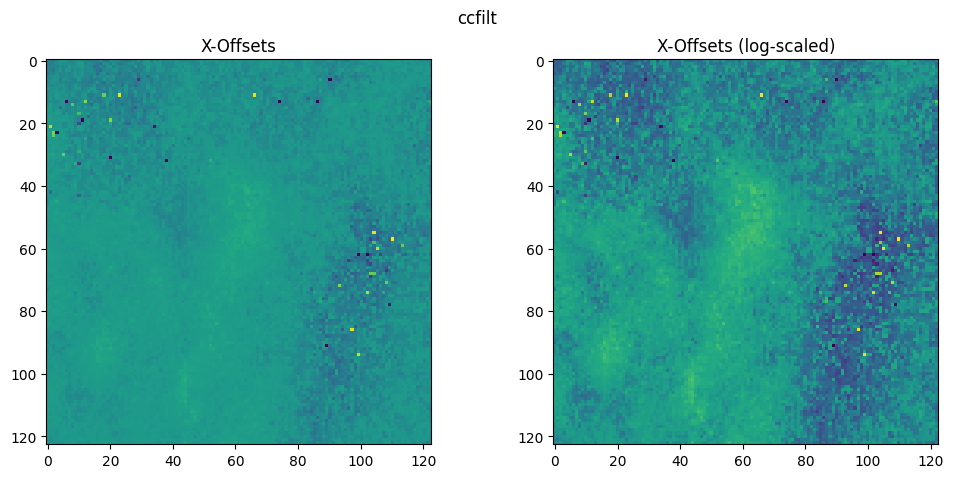

In [3]:
axis_index = 1
dirs = [out_off_dir, out_off_dir_ccfilt]

off_data: np.ndarray = None
off_outliers: list[tuple[tuple[int, int], float]] = []
off_control: list[tuple[tuple[int, int], float]] = []
off_offset: float = 0

# visualize both the original offsets, and the offsets after the cross
# correlation filter is applied
for i, dir in enumerate(dirs):
	# load offset data
	files = get_fits_paths(dir)
	data = load_image_data(files[-1], None, None)

	# log-scale the offsets so smaller structures are visible
	data_logscl = data.copy()
	data_logscl -= np.median(data_logscl)
	data_logscl = np.sign(data_logscl) * np.log1p(np.abs(data_logscl))
	
	# normalize logscaled offs
	min_logscl = data_logscl.min()
	range_logscl = max(0.1, data_logscl.max() - min_logscl)
	data_logscl = (data_logscl - min_logscl) / range_logscl
	
	# normalize offs
	data_min = data.min()
	data_max = data.max()
	data_range = max(data_max - data_min, 0.1)
	data = (data - data_min) / data_range

	# save some data about offsets outside the loop
	if i == 0:
		off_offset = data_min / data_range
		off_data = data[axis_index]
		off_lower = np.percentile(off_data, 5)
		off_upper = np.percentile(off_data, 95)
		off_iqr = off_upper - off_lower
		shift_thresh = off_iqr * 2 #+ 0.5 * kernel_sizes[-1] / data_range
		outlier_mask = (off_data < off_lower - shift_thresh) | (off_data > off_upper + shift_thresh)
		outlier_indices = list(map(tuple, np.column_stack(np.where(outlier_mask))))
		off_outliers = [
			(i, off_data[i])
			for i in outlier_indices
		]
		control_mask = (
			(off_data > np.percentile(off_data, 25)) &
			(off_data < np.percentile(off_data, 75))
		)
		control_indices = list(map(tuple, np.column_stack(np.where(control_mask))))
		control_indices_flat = [
			random.choice(control_indices)
			for x in range(0, len(off_outliers))
		]
		off_control = [
			(i, off_data[i])
			for i in control_indices_flat
		]

	# plot the images
	plt.figure(figsize=(12,5))
	
	plt.subplot(1,2,1)
	plt.imshow(data[axis_index, :, :], vmin=0, vmax=1)
	plt.title(f"{"YX"[axis_index]}-Offsets")
	
	plt.subplot(1,2,2)
	plt.imshow(data_logscl[axis_index, :, :], vmin=0, vmax=1)
	plt.title(f"{"YX"[axis_index]}-Offsets (log-scaled)")
	
	plt.suptitle(dir.split('/')[-1])
	plt.show()


# Inspect cross correlations for artifacts

480349.82929939165
2637751.638872078


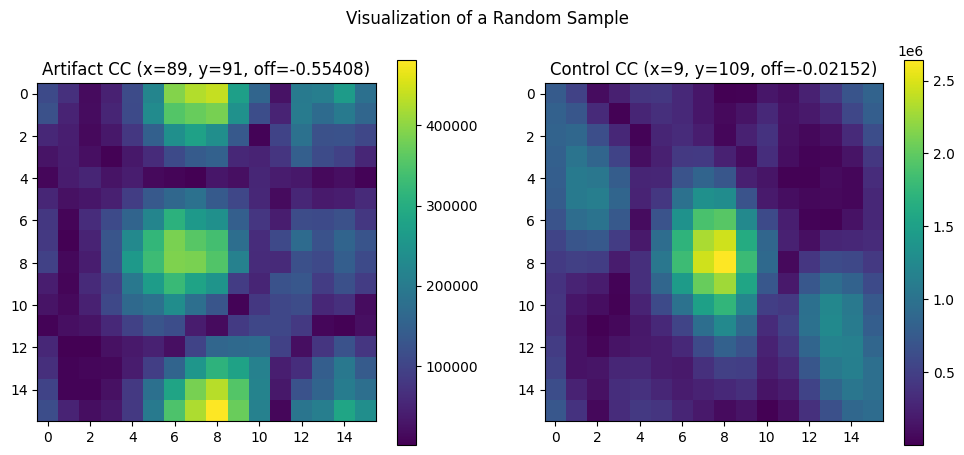

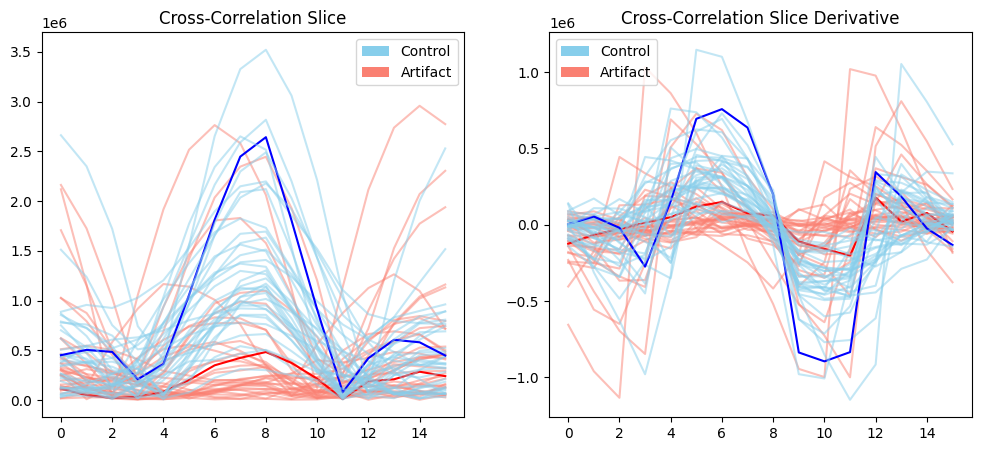

In [49]:
# pick random artifact from outliers
artifact = random.choice(off_outliers)[0]

# control point (no artifact)
control = random.choice(off_control)[0]
cc_size = kernel_sizes[-1]

# artifact cross correlation data
cca_index_x = cc_size * artifact[0]
cca_index_y = cc_size * artifact[1]
artifact_cross_correlation = algorithm.SUBFIELD_CORRS[
    axis_index,  
    cca_index_x : cca_index_x + cc_size,
    cca_index_y : cca_index_y + cc_size, 
]
cca_corr = artifact_cross_correlation.max()
cca_corr_min = artifact_cross_correlation.min()

# control cross correlation data
ccc_index_x = cc_size * control[0]
ccc_index_y = cc_size * control[1]
control_cross_correlation = algorithm.SUBFIELD_CORRS[
    axis_index,
    ccc_index_x : ccc_index_x + cc_size,
    ccc_index_y : ccc_index_y + cc_size,
]
ccc_corr = control_cross_correlation.max()
ccc_corr_min = control_cross_correlation.min()

print(cca_corr - cca_corr_min) 
print(ccc_corr - ccc_corr_min)

# plot the cross correlations
rounding_amount = 1e5
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(artifact_cross_correlation)
plt.title(f"Artifact CC (x={artifact[1]}, y={artifact[0]}, off={
	round((off_data[artifact] + off_offset) * rounding_amount) / rounding_amount
})")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(control_cross_correlation)
plt.title(f"Control CC (x={control[1]}, y={control[0]}, off={round((off_data[control] + off_offset) * rounding_amount) / rounding_amount})")
plt.colorbar()

plt.suptitle("Visualization of a Random Sample")
plt.show()

# plot the vertical slices and derivatives to see their shapes better
plt.figure(figsize=(12,5))
color_control = "skyblue"
color_artifact = "salmon"

for arr in [off_outliers, off_control]:
	base_col = color_artifact if arr == off_outliers else color_control
	highlight_col = "red" if arr == off_outliers else "blue"
	for xy, shift in arr:
		wx = xy[0] * cc_size
		wy = xy[1] * cc_size
		cc_window = (correlations[
			axis_index,
			wx : wx + cc_size,
			wy : wy + cc_size,
		])
		cc_max_index = np.argmax(cc_window)
		cc_max_index_x = math.floor(cc_max_index / cc_size)
		cc_max_index_y = int(cc_max_index_x % cc_size)
		slice = cc_window[cc_max_index_x]

		alpha = 0.5
		color = base_col
		if (xy[0] == artifact[0] and xy[1] == artifact[1]) or (xy[0] == control[0] and xy[1] == control[1]): 
			alpha = 1
			color = highlight_col

		plt.subplot(1,2,1)
		plt.plot(slice, color=color, alpha=alpha)

		plt.subplot(1,2,2)
		slice = [
			x - slice[i-1]
			for i, x in enumerate(slice)
		]
		plt.plot(slice, color=color, alpha=alpha)

plt.subplot(1,2,1)
plt.title("Cross-Correlation Slice")
plt.legend(handles=[
	Patch(facecolor=color_control, label="Control"),
	Patch(facecolor=color_artifact, label="Artifact"),
])

plt.subplot(1,2,2)
plt.title("Cross-Correlation Slice Derivative")
plt.legend(handles=[
	Patch(facecolor=color_control, label="Control"),
	Patch(facecolor=color_artifact, label="Artifact"),
])

plt.show()

# There are some differences here between the artifact and control but not consistent enough to be useful

------------------------

# Now we will try comparing cross correlation radial averages

15 76 (np.int64(13), np.int64(86))
86 13 (np.int64(13), np.int64(86))


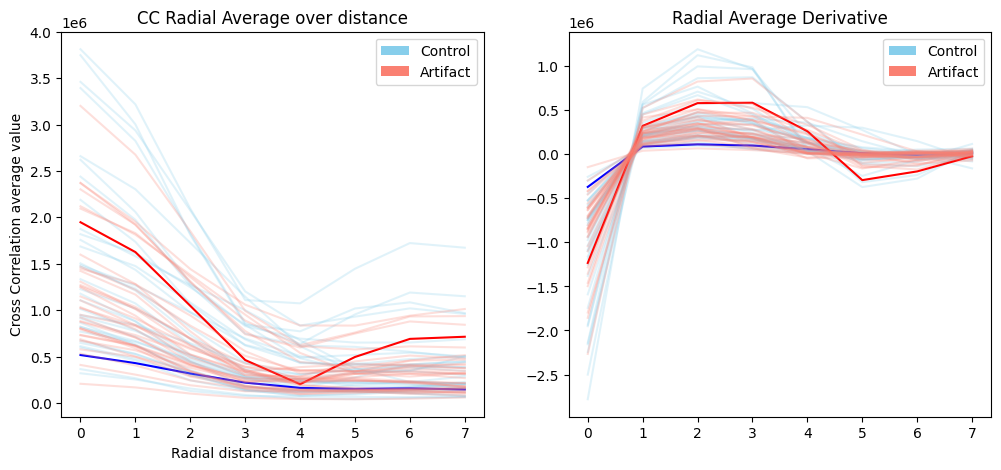

In [48]:
# Smooth transition band
def smoothstep(edge0: float, edge1: float, r: np.ndarray) -> np.ndarray:
	t = np.clip((r - edge0) / (edge1 - edge0), 0, 1)
	# cubic Hermite interpolation
	return t * t * (3 - 2 * t)  

def smooth_radial_average(
	arr: np.ndarray, 
	center: tuple[float, float], 
	r_min: float, 
	r_max:float,
	transition: float=0.5
) -> float:
	ny, nx = arr.shape
	y, x = np.ogrid[:ny, :nx]
	cy, cx = center
	r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)

	# create radial mask
	mask_inner = smoothstep(r_min - transition, r_min + transition, r)
	mask_outer = 1 - smoothstep(r_max - transition, r_max + transition, r)
	mask = mask_inner * mask_outer

	# if mask does not overlap array, return 0
	total_weight = np.sum(mask)
	if total_weight == 0:
		return 0.0
	
	# find the average of the masked array
	return np.sum(arr * mask) / total_weight

def plot_avgs(subwindow_positions: list[tuple[int, int]], color, alpha: float , highlight_col):
	for y, x in subwindow_positions:
		wx = x * cc_size
		wy = y * cc_size
		cc_window = (correlations[
			axis_index,
			wx : wx + cc_size,
			wy : wy + cc_size,
		])
		cc_max_index = np.argmax(cc_window)
		cc_max_index_x = math.floor(cc_max_index / cc_size)
		cc_max_index_y = int(cc_max_index % cc_size)

		radial_samples = 8
		avgs = np.zeros((radial_samples))
		for i in range(0, radial_samples):
			avg = smooth_radial_average(
				cc_window, 
				(cc_max_index_x, cc_max_index_y),
				i, i + 1
			)
			avgs[i] = avg
		plt.subplot(1,2,1)
		col = color
		alph = alpha
		if (x == artifact[1] and y == artifact[0]) or (x == control[1] and y == control[0]): 
			print(x, y, artifact)
			alph = 1
			col = highlight_col
		plt.plot(avgs, color=col, alpha=alph)

		plt.subplot(1,2,2)
		deriv = [
			avgs[i-1] - x
			for i, x in enumerate(avgs)
		]
		plt.plot(deriv, color=col, alpha=alph)

# plot the radial averages of the controls and the artifacts
control_windows = [ x[0] for x in off_control ]
artifact_windows = [ x[0] for x in off_outliers ]
plt.figure(figsize=(12,5))

plot_avgs(control_windows, color_control, 0.25, "blue")
plot_avgs(artifact_windows, color_artifact, 0.25, "red")

# format plot
plt.subplot(1,2,1)
plt.title("CC Radial Average over distance")
plt.xlabel("Radial distance from maxpos")
plt.ylabel("Cross Correlation average value")
plt.legend(handles=[
	Patch(facecolor=color_control, label="Control"),
	Patch(facecolor=color_artifact, label="Artifact"),
])

plt.subplot(1,2,2)
plt.title("Radial Average Derivative")
plt.legend(handles=[
	Patch(facecolor=color_control, label="Control"),
	Patch(facecolor=color_artifact, label="Artifact"),
])

# No noticeable differences ¯\\\_(ツ)_/¯

-------

# We'll try looking at differences between local maxima on the cross correlation

In [58]:
cca_maxima = np.argwhere(
    artifact_cross_correlation == 
    maximum_filter(artifact_cross_correlation, size=3)
)
ccc_maxima = np.argwhere(
    control_cross_correlation == 
    maximum_filter(control_cross_correlation, size=3)
)

print(cca_maxima)

[[ 0  8]
 [ 0 14]
 [ 1  0]
 [ 4  2]
 [ 7 12]
 [ 7 14]
 [ 8  0]
 [ 8  6]
 [ 9 12]
 [15  0]
 [15  8]
 [15 14]]
